### Testing code functionality
Amy - Sep 2026

***Maria's note***:
**Changes from Amy's notebook (dataset setup):**
- 20 x 20 D–T2 points instead of 10 x 10.
- 8 b-values (0-4) s 8 TEs (20–180 ms) instead of 20 b-values (0–10) s 20 TEs (10–200 ms), so far fewer measurements per voxel
- More voxels, 80 instead of 12.
- SVD rank R = 10 instead of 8
- New true compartments, the same as in demo_pipeline: centres at (D, T2) = (0.4, 90), (0.9, 55), (1.6, 120), with a different width for each
- Added a mean version of the NNLS initialisation (define_initial_C_NNLS_mean in optimiser), which averages the signals before solving NNLS
- Sections 3 and 4 use their own fixed random seed, so they run on the same data and can be compared


#### First create some GT spectra

In [34]:
"""
Preprocessing script for sub-M1 MultiDim DWI data.
- Loads the selected runs (one TE per run)
- Averages volumes sharing the same b-value within each run (powder average)
- Uses a WM mask from FSL FAST PVE output (fast_pve_1.nii.gz for this ex vivo data)
- Outputs Y matrix of shape (nTE * nB, V), rows ordered TE-major then b

FSL steps (run in a terminal beforehand, output into OUT_DIR):
    bet4animal b0_mean.nii.gz brain -z 1 -f 0.3 -m
    fast -t 2 -n 3 -o fast brain.nii.gz        # -t 2 = T2-weighted input
The PVE map must be on the same voxel grid as the raw DWI runs (checked below).
"""

import os
import numpy as np
import nibabel as nib

# ---------------------------------------------
# 0. CONFIGURATION
# ---------------------------------------------
DATA_DIR = "/Users/mb4725/Library/CloudStorage/OneDrive-ImperialCollegeLondon/PhD/Code/Dataset_macaque"
OUT_DIR  = os.path.join(DATA_DIR, "preprocessed")
os.makedirs(OUT_DIR, exist_ok=True)

# TE (ms) for each run
TE_BY_RUN = {1: 28.12, 2: 33.0, 3: 38.017, 4: 45.0, 5: 60.0, 6: 78.0}

# Runs to use. Runs 1 and 3 have a different diffusion time (Delta) from the rest;
# use [2, 4, 5, 6] for a single-Delta D-T2 fit (then 43000 can be added to COMMON_BVALS).
RUNS = [1, 2, 3, 4, 5, 6]

# b-values shared across ALL selected runs (s/mm2)
COMMON_BVALS = np.array([0.0, 1000.0, 2500.0, 5000.0, 7500.0, 11100.0, 18100.0, 25000.0])

BVAL_TOL = 50.0   # tolerance for b-value matching (s/mm2)

# Ex vivo contrast reorders FAST's classes: here pve_1 = WM, pve_0 = GM, pve_2 = fluid/edges
FAST_PVE_WM_PATH = os.path.join(OUT_DIR, "fast_pve_1.nii.gz")
PVE_THRESHOLD    = 0.9   # near-pure WM only, avoids GM/WM and ventricle partial volume

TE_vals = np.array([TE_BY_RUN[r] for r in RUNS])


# ---------------------------------------------
# 1. HELPER FUNCTIONS
# ---------------------------------------------
def load_bvals(run_idx):
    path = os.path.join(DATA_DIR, f"sub-M1_acq-MultiDim_run-{run_idx}_dwi.bval")
    return np.loadtxt(path).ravel()


def load_nifti(run_idx):
    path = os.path.join(DATA_DIR, f"sub-M1_acq-MultiDim_run-{run_idx}_dwi.nii.gz")
    img  = nib.load(path)
    return img.get_fdata(dtype=np.float32), img.affine, img.header


def average_by_bval(data4d, bvals, target_bvals, tol=BVAL_TOL):
    x, y, z, _ = data4d.shape
    averaged = np.zeros((x, y, z, len(target_bvals)), dtype=np.float32)
    counts   = np.zeros(len(target_bvals), dtype=int)
    used     = np.zeros(len(bvals), dtype=bool)

    for i, bval in enumerate(target_bvals):
        sel = np.abs(bvals - bval) <= tol
        n   = sel.sum()
        if n == 0:
            # a missing shell would leave zeros in Y, so stop instead of warning
            raise ValueError(f"No volumes for b={bval:.0f} s/mm2 in this run "
                             f"(b-values present: {np.unique(np.round(bvals, -1))})")
        averaged[..., i] = data4d[..., sel].mean(axis=-1)
        counts[i] = n
        used |= sel
        print(f"  b={bval:>6.0f} s/mm2  ->  averaged {n} volumes")

    if (~used).any():
        print(f"  Not used (outside COMMON_BVALS): {np.unique(np.round(bvals[~used], -1))}")
    return averaged, counts


# ---------------------------------------------
# 2. LOAD WM MASK FROM FAST PVE
# ---------------------------------------------
def generate_wm_mask():
    print("Loading WM mask from FSL FAST PVE output...")
    pve_img  = nib.load(FAST_PVE_WM_PATH)
    pve_data = pve_img.get_fdata(dtype=np.float32)
    print(f"  PVE map shape: {pve_data.shape}")
    print(f"  PVE range: [{pve_data.min():.3f}, {pve_data.max():.3f}]")

    wm_mask = pve_data > PVE_THRESHOLD
    nib.save(nib.Nifti1Image(wm_mask.astype(np.uint8), pve_img.affine, pve_img.header),
             os.path.join(OUT_DIR, "wm_mask.nii.gz"))
    print(f"  WM mask: {wm_mask.sum()} voxels (PVE > {PVE_THRESHOLD})")
    return wm_mask, pve_img.affine


# ---------------------------------------------
# 3. MAIN PREPROCESSING LOOP
# ---------------------------------------------
def preprocess():
    wm_mask, wm_affine = generate_wm_mask()
    n_voxels = wm_mask.sum()

    nB, nTE = len(COMMON_BVALS), len(RUNS)
    averaged_runs = []

    print("\nProcessing runs...")
    for run_idx in RUNS:
        print(f"\n-- Run {run_idx}  (TE = {TE_BY_RUN[run_idx]:.3f} ms) --")
        data, affine, header = load_nifti(run_idx)
        bvals = load_bvals(run_idx)
        print(f"  Data shape: {data.shape}  |  Unique b-values: {np.unique(np.round(bvals, -1))}")

        # the mask indexes voxels directly, so it must be on the same grid
        if data.shape[:3] != wm_mask.shape or not np.allclose(affine, wm_affine, atol=1e-3):
            raise ValueError(f"Run {run_idx} grid {data.shape[:3]} does not match WM mask "
                             f"{wm_mask.shape} (was FAST run on a reoriented/cropped image?)")

        avg, _ = average_by_bval(data, bvals, COMMON_BVALS)
        averaged_runs.append(avg)
        nib.save(nib.Nifti1Image(avg, affine, header),
                 os.path.join(OUT_DIR, f"run-{run_idx}_averaged.nii.gz"))
        del data

    # ---------------------------------------------
    # 4. BUILD Y MATRIX  shape: (nTE * nB, V)
    # ---------------------------------------------
    print("\nBuilding Y matrix...")
    all_wm = np.stack([avg[wm_mask] for avg in averaged_runs], axis=0)  # (nTE, V, nB)
    Y = all_wm.transpose(0, 2, 1).reshape(nTE * nB, n_voxels)           # (nTE*nB, V)

    # acquisition table matching Y's rows: (b, TE)
    acq = np.column_stack([np.tile(COMMON_BVALS, nTE), np.repeat(TE_vals, nB)])
    print(f"  Y shape: {Y.shape}  ->  ({nTE} TEs x {nB} b-vals, {n_voxels} WM voxels)")

    # ---------------------------------------------
    # 5. SAVE OUTPUTS
    # ---------------------------------------------
    np.save(os.path.join(OUT_DIR, "Y_real.npy"),       Y)
    np.save(os.path.join(OUT_DIR, "TE_vals.npy"),      TE_vals)
    np.save(os.path.join(OUT_DIR, "bvals_common.npy"), COMMON_BVALS)
    np.save(os.path.join(OUT_DIR, "acq_table.npy"),    acq)
    np.save(os.path.join(OUT_DIR, "wm_mask.npy"),      wm_mask)
    print(f"\nAll outputs saved to: {OUT_DIR}")

    return Y, TE_vals, COMMON_BVALS, wm_mask


# ---------------------------------------------
# 6. RUN + SANITY CHECKS
# ---------------------------------------------
if __name__ == "__main__":
    Y, TE_vals, bvals, wm_mask = preprocess()
    nB = len(bvals)

    print("\nSanity check:")
    print(f"  Y min / max / mean: {Y.min():.4f} / {Y.max():.4f} / {Y.mean():.4f}")
    print(f"  Any NaN: {np.isnan(Y).any()}   Any Inf: {np.isinf(Y).any()}")

    # b=0 WM signal should fall smoothly with TE; jumps mean runs are scaled differently
    s0 = Y[0::nB].mean(axis=1)
    slope = np.polyfit(TE_vals, np.log(s0), 1)[0]
    print("  Mean WM b=0 per TE:", {float(t): round(float(s), 1) for t, s in zip(TE_vals, s0)})
    print(f"  Mono-exponential WM T2 ~ {-1 / slope:.1f} ms")
    if np.any(np.diff(s0) > 0):
        print("  ! b=0 signal increases with TE somewhere: check scaling between runs")

Loading WM mask from FSL FAST PVE output...
  PVE map shape: (120, 140, 72)
  PVE range: [0.000, 1.000]
  WM mask: 97016 voxels (PVE > 0.9)

Processing runs...

-- Run 1  (TE = 28.120 ms) --
  Data shape: (120, 140, 72, 151)  |  Unique b-values: [    0.  1000.  2500.  5000.  7500. 11100. 18100. 25000.]
  b=     0 s/mm2  ->  averaged 7 volumes
  b=  1000 s/mm2  ->  averaged 12 volumes
  b=  2500 s/mm2  ->  averaged 12 volumes
  b=  5000 s/mm2  ->  averaged 12 volumes
  b=  7500 s/mm2  ->  averaged 12 volumes
  b= 11100 s/mm2  ->  averaged 32 volumes
  b= 18100 s/mm2  ->  averaged 32 volumes
  b= 25000 s/mm2  ->  averaged 32 volumes

-- Run 2  (TE = 33.000 ms) --
  Data shape: (120, 140, 72, 184)  |  Unique b-values: [    0.  1000.  2500.  5000.  7500. 11100. 18100. 25000. 43000.]
  b=     0 s/mm2  ->  averaged 8 volumes
  b=  1000 s/mm2  ->  averaged 12 volumes
  b=  2500 s/mm2  ->  averaged 12 volumes
  b=  5000 s/mm2  ->  averaged 12 volumes
  b=  7500 s/mm2  ->  averaged 12 volumes
 

Slice 42: 3679 WM voxels

-- Run 1  (TE = 28.120 ms) --
  b=     0  ->  averaged 7 volumes
  b=  1000  ->  averaged 12 volumes
  b=  2500  ->  averaged 12 volumes
  b=  5000  ->  averaged 12 volumes
  b=  7500  ->  averaged 12 volumes
  b= 11100  ->  averaged 32 volumes
  b= 18100  ->  averaged 32 volumes
  b= 25000  ->  averaged 32 volumes

-- Run 2  (TE = 33.000 ms) --
  b=     0  ->  averaged 8 volumes
  b=  1000  ->  averaged 12 volumes
  b=  2500  ->  averaged 12 volumes
  b=  5000  ->  averaged 12 volumes
  b=  7500  ->  averaged 12 volumes
  b= 11100  ->  averaged 32 volumes
  b= 18100  ->  averaged 32 volumes
  b= 25000  ->  averaged 32 volumes

-- Run 3  (TE = 38.017 ms) --
  b=     0  ->  averaged 9 volumes
  b=  1000  ->  averaged 12 volumes
  b=  2500  ->  averaged 12 volumes
  b=  5000  ->  averaged 12 volumes
  b=  7500  ->  averaged 12 volumes
  b= 11100  ->  averaged 32 volumes
  b= 18100  ->  averaged 32 volumes
  b= 25000  ->  averaged 32 volumes

-- Run 4  (TE = 45.0

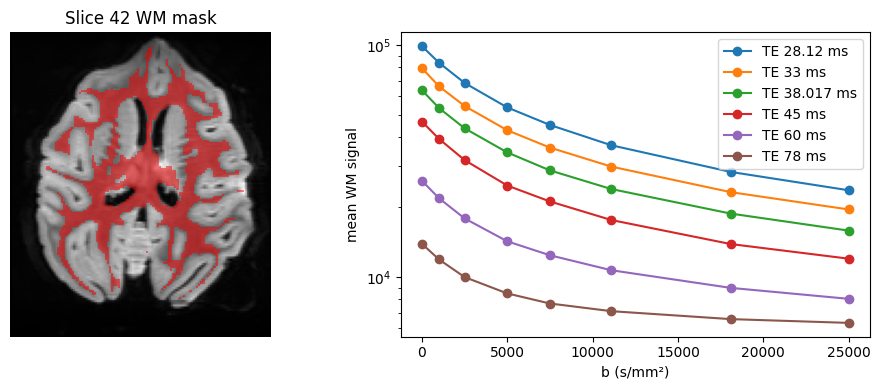

In [36]:
"""
Build the D-T2 signal matrix Y for ONE axial slice of sub-M1, using WM_mask_dwispace.nii.gz.

- Reads only the chosen slice from each run (low memory, fast)
- Averages volumes sharing the same b-value within each run (powder average)
- Y shape: (nTE * nB, V), rows ordered TE-major then b; acq_table gives (b, TE) per row
"""

import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

# ---------------------------------------------
# 0. CONFIGURATION
# ---------------------------------------------
DATA_DIR  = "/Users/mb4725/Library/CloudStorage/OneDrive-ImperialCollegeLondon/PhD/Code/Dataset_macaque"
OUT_DIR   = os.path.join(DATA_DIR, "preprocessed")
MASK_PATH = os.path.join(OUT_DIR, "WM_mask_dwispace.nii.gz")
os.makedirs(OUT_DIR, exist_ok=True)

SLICE_IDX = 42    # axial (3rd axis) slice; 42 has the most WM voxels (3679)

TE_BY_RUN = {1: 28.12, 2: 33.0, 3: 38.017, 4: 45.0, 5: 60.0, 6: 78.0}
RUNS      = [1, 2, 3, 4, 5, 6]   # [2, 4, 5, 6] = single diffusion time only
COMMON_BVALS = np.array([0.0, 1000.0, 2500.0, 5000.0, 7500.0, 11100.0, 18100.0, 25000.0])
BVAL_TOL  = 50.0

TE_vals = np.array([TE_BY_RUN[r] for r in RUNS])


# ---------------------------------------------
# 1. MASK FOR THE SLICE
# ---------------------------------------------
mask_img   = nib.load(MASK_PATH)
mask_slice = mask_img.get_fdata()[:, :, SLICE_IDX] > 0
n_voxels   = int(mask_slice.sum())
print(f"Slice {SLICE_IDX}: {n_voxels} WM voxels")


# ---------------------------------------------
# 2. PER-RUN SHELL AVERAGES ON THE SLICE
# ---------------------------------------------
def load_slice(run_idx):
    path = os.path.join(DATA_DIR, f"sub-M1_acq-MultiDim_run-{run_idx}_dwi.nii.gz")
    img  = nib.load(path)
    if img.shape[:3] != mask_img.shape or not np.allclose(img.affine, mask_img.affine, atol=1e-3):
        raise ValueError(f"Run {run_idx} grid {img.shape[:3]} does not match mask {mask_img.shape}")
    return np.asarray(img.dataobj[:, :, SLICE_IDX, :], dtype=np.float32)   # (x, y, nvol)


def load_bvals(run_idx):
    path = os.path.join(DATA_DIR, f"sub-M1_acq-MultiDim_run-{run_idx}_dwi.bval")
    return np.loadtxt(path).ravel()


rows = []
for run_idx in RUNS:
    print(f"\n-- Run {run_idx}  (TE = {TE_BY_RUN[run_idx]:.3f} ms) --")
    data  = load_slice(run_idx)[mask_slice]          # (V, nvol)
    bvals = load_bvals(run_idx)
    for bval in COMMON_BVALS:
        sel = np.abs(bvals - bval) <= BVAL_TOL
        if not sel.any():
            raise ValueError(f"No volumes for b={bval:.0f} in run {run_idx}")
        rows.append(data[:, sel].mean(axis=1))
        print(f"  b={bval:>6.0f}  ->  averaged {sel.sum()} volumes")


# ---------------------------------------------
# 3. BUILD Y AND SAVE
# ---------------------------------------------
nB, nTE = len(COMMON_BVALS), len(RUNS)
Y   = np.stack(rows)                                                      # (nTE*nB, V)
acq = np.column_stack([np.tile(COMMON_BVALS, nTE), np.repeat(TE_vals, nB)])  # (b, TE)
voxel_xy = np.argwhere(mask_slice)                                        # to map columns back

tag = f"slice{SLICE_IDX}"
np.save(os.path.join(OUT_DIR, f"Y_{tag}.npy"),        Y)
np.save(os.path.join(OUT_DIR, f"acq_table_{tag}.npy"), acq)
np.save(os.path.join(OUT_DIR, f"voxel_xy_{tag}.npy"),  voxel_xy)
np.save(os.path.join(OUT_DIR, "TE_vals.npy"),           TE_vals)
np.save(os.path.join(OUT_DIR, "bvals_common.npy"),      COMMON_BVALS)
print(f"\nY shape: {Y.shape}  ({nTE} TEs x {nB} b-values, {n_voxels} voxels)")


# ---------------------------------------------
# 4. SANITY CHECKS
# ---------------------------------------------
print(f"Any NaN: {np.isnan(Y).any()}   Any Inf: {np.isinf(Y).any()}")
s0 = Y[0::nB].mean(axis=1)
print("Mean WM b=0 per TE:", {float(t): round(float(s), 1) for t, s in zip(TE_vals, s0)})
print(f"Mono-exponential WM T2 ~ {-1 / np.polyfit(TE_vals, np.log(s0), 1)[0]:.1f} ms")
if np.any(np.diff(s0) > 0):
    print("! b=0 signal increases with TE somewhere: check scaling between runs")

b0_slice = load_slice(RUNS[0])[..., np.abs(load_bvals(RUNS[0])) <= BVAL_TOL].mean(-1)
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(b0_slice.T, cmap="gray", origin="lower")
ax[0].imshow(np.ma.masked_where(~mask_slice.T, mask_slice.T), cmap="autumn", alpha=0.5, origin="lower")
ax[0].set_title(f"Slice {SLICE_IDX} WM mask"); ax[0].axis("off")
for i, te in enumerate(TE_vals):
    ax[1].semilogy(COMMON_BVALS, Y[i * nB:(i + 1) * nB].mean(1), "o-", label=f"TE {te:g} ms")
ax[1].set_xlabel("b (s/mm²)"); ax[1].set_ylabel("mean WM signal"); ax[1].legend()
plt.tight_layout(); plt.show()

In [3]:
from pathlib import Path
import sys, numpy as np, matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
root=Path.cwd().resolve(); root=root if (root/'create_grid.py').exists() else root.parent; sys.path.insert(0,str(root))
from create_grid import *
from optimiser_alpha_gamma import *
from metrics import voxelwise_spectrum_mae

rng=np.random.default_rng(40)

In [4]:
def show_canonical_spectra(items):
    fig, axes = plt.subplots(len(items), K, figsize=(3*K, 3*len(items)), squeeze=False)
    for row, (title, C) in enumerate(items):
        for k in range(K):
            axes[row, k].imshow(C[:, k].reshape(len(D_vals), len(T2_vals)), origin='lower', aspect='auto',
                extent=[T2_vals.min(), T2_vals.max(), D_vals.min(), D_vals.max()])
            axes[row, k].set_title(f'{title}, component {k+1}')
            axes[row, k].set_xlabel('T2'); axes[row, k].set_ylabel('D')
    plt.tight_layout()
    plt.show()


def show_voxelwise_spectra(F_true, F_est, W_true, W_est, voxels_to_show=[0, 5, 12, 17]):
    fig, axes = plt.subplots(
        3, len(voxels_to_show),
        figsize=(3.2 * len(voxels_to_show), 8.5),
        constrained_layout=True,
    )

    for col, voxel in enumerate(voxels_to_show):
        for row, (name, F) in enumerate([("Ground truth", F_true), ("Estimated", F_est)]):
            image = axes[row, col].imshow(
                F[:, voxel].reshape(nD, nT2),
                origin="lower",
                aspect="auto",
                extent=[T2_vals.min(), T2_vals.max(), D_vals.min(), D_vals.max()],
            )
            axes[row, col].set_title(f"{name}: voxel {voxel}")
            axes[row, col].set_xlabel("T2 (ms)")
            axes[row, col].set_ylabel("D")
            fig.colorbar(image, ax=axes[row, col], shrink=0.75)

        # The third row reports the component weights that form this spectrum.
        components = np.arange(W_true.shape[0])
        axes[2, col].bar(components - 0.18, W_true[:, voxel], 0.36, label="Ground truth")
        axes[2, col].bar(components + 0.18, W_est[:, voxel], 0.36, label="Estimated")
        axes[2, col].set(xticks=components, xticklabels=[f"W{k + 1}" for k in components],
                         ylim=(0, 1), title=f"Weights: voxel {voxel}", ylabel="weight")
        if col == 0:
            axes[2, col].legend()

    plt.show()

def order_components(C_true, C_est, W_est, K):
    # Cost[i, j] = dissimilarity between true component i and estimated component j.
    cost = np.array([
        [np.mean((C_true[:, i] - C_est[:, j]) ** 2) for j in range(K)]
        for i in range(K)
    ])

    true_indices, estimated_indices = linear_sum_assignment(cost)

    # Put estimated components into the ground-truth component order.
    order = estimated_indices[np.argsort(true_indices)]

    C_est = C_est[:, order]
    W_est = W_est[order, :]
    return C_est, W_est

b values  [ 0.   1.   2.5  5.   7.5 11.1 18.1 25. ] 

TE values  [28.12  33.    38.017 45.    60.    78.   ] 

Y shape  (48, 100) 



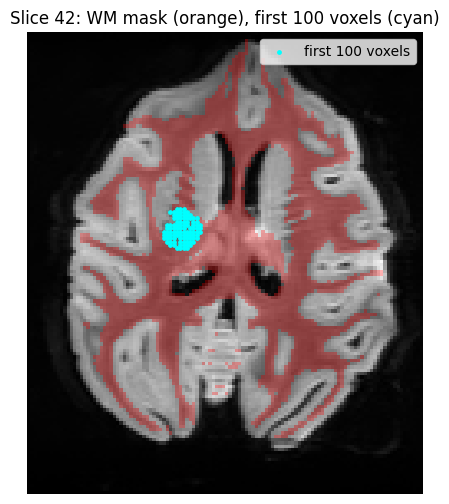

In [71]:
Dmin, T2min, Dmax, T2max, nD, nT2 = 0.01, 10.0, 1.5, 150.0, 20, 20   # ex vivo: lower D range

voxels_to_show = [10, 20, 30, 40, 50, 60, 70]

D_grid, T2_grid = create_DT2_grid(Dmin, Dmax, nD, T2min, T2max, nT2)
D_vals = np.linspace(Dmin, Dmax, nD)
T2_vals = np.linspace(T2min, T2max, nT2)

# Load real signal (one slice, WM mask)
OUT = "/Users/mb4725/Library/CloudStorage/OneDrive-ImperialCollegeLondon/PhD/Code/Dataset_macaque/preprocessed"
Y = np.load(f"{OUT}/Y_slice42.npy")             # (nTE*nB, V)
acq = np.load(f"{OUT}/acq_table_slice42.npy")   # columns: b [s/mm²], TE [ms]
voxel_xy = np.load(f"{OUT}/voxel_xy_slice42.npy")

cx, cy = 46, 80   # ROI centre (x, y) in voxels, read off the map
near = np.argsort(np.hypot(voxel_xy[:, 0] - cx, voxel_xy[:, 1] - cy))[:100]
Y, voxel_xy = Y[:, near], voxel_xy[near]  # every 37th voxel, 100 spread across the slice    # first 100 voxels only

b_list = acq[:, 0] / 1000.0    # s/mm² -> ms/µm² (same units as D)
TE_list = acq[:, 1]
b_vals = np.unique(b_list)
TE_vals = np.unique(TE_list)
print("b values ", b_vals, "\n")
print("TE values ", TE_vals, "\n")
print("Y shape ", Y.shape, "\n")

Y = Y / np.median(Y[0]) * 300   # scale so M0 ≈ 300, like the simulations

# Define fitting parameters
K=3; # Number of canonical spectra
V=Y.shape[1]; # Number of voxels
R=20   # Rank for SVD

D,T2=create_DT2_grid(Dmin,Dmax,nD,T2min,T2max,nT2);
# Create A matrix from the real acquisition (rows match Y)
A = np.exp(-np.outer(b_list, D)) * np.exp(-np.outer(TE_list, 1.0 / T2));

# reorder rows b-major (b outer, TE inner), like create_A_matrix's grid
order = np.lexsort((TE_list, b_list))
Y, A = Y[order], A[order]
b_list, TE_list = b_list[order], TE_list[order]
U, s, Vmat = apply_SVD_to_A(A, R)

plt.figure(figsize=(6, 6))
plt.imshow(b0_slice.T, cmap="gray", origin="lower")
plt.imshow(np.ma.masked_where(~mask_slice.T, mask_slice.T), cmap="autumn", alpha=0.3, origin="lower")
plt.scatter(voxel_xy[:, 0], voxel_xy[:, 1], s=6, c="cyan", label="first 100 voxels")
plt.title(f"Slice {SLICE_IDX}: WM mask (orange), first 100 voxels (cyan)")
plt.legend(loc="upper right"); plt.axis("off"); plt.show()

#### Run optimisation

I added a function, define_initial_C_NNLS_mean, that averages the signals over all voxels first and then solves one NNLS on the average. The original define_initial_C_NNLS solves NNLS on each voxel and averages the spectra. Both then use k-means on the averaged spectrum to find the component centres and place one Gaussian at each centre.

**Result:** The original (spectrum-averaged) version puts the components in the wrong places here. The new signal-averaged version finds all three in the right places. Only the second is kept, so everything below starts from the signal-averaged initialisation.


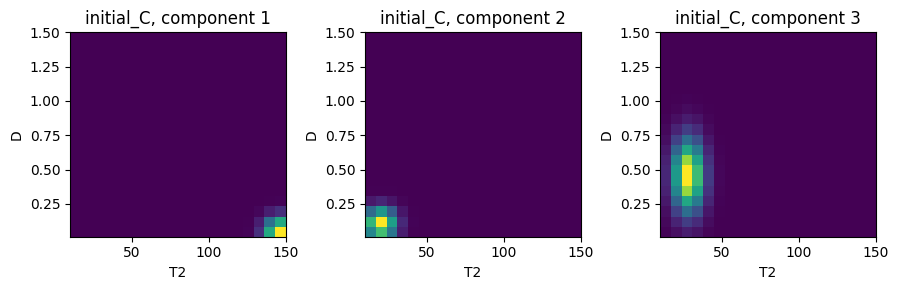

Initial M0 (median, range): 1028.74245744117 825.6404193713886 1393.5112611503864


In [72]:
# Set initial conditions
C0=define_initial_C_NNLS_mean(Y,A,range(V),K,D_vals,T2_vals,D_vals.min(),D_vals.max(),T2_vals.min(),T2_vals.max(),nD,nT2)
Csmall0=project_C_to_C_small(C0,s,Vmat);

M0_init = initialize_M0_monoexponential(Y, b_vals, TE_vals)

W0 = initialize_W_from_C(Y, U, Csmall0, M0_init, bound_eps=1e-3)

# no C_true to match against: order components by mean D (low to high)
D_centroid = (D @ C0) / C0.sum(axis=0)
idx = np.argsort(D_centroid)
C0, W0 = C0[:, idx], W0[idx]
Csmall0 = project_C_to_C_small(C0, s, Vmat)

show_canonical_spectra([('initial_C', C0)])
print("Initial M0 (median, range):", np.median(M0_init), M0_init.min(), M0_init.max())

sigma2 from initial fit: 140.1558707177177
iter 0: loss=750.4584, fit_err=229784.337386, sigma2=140.155871
iter 100: loss=339.3441, fit_err=114551.140267, sigma2=140.155871
iter 200: loss=339.3440, fit_err=114551.130836, sigma2=140.155871


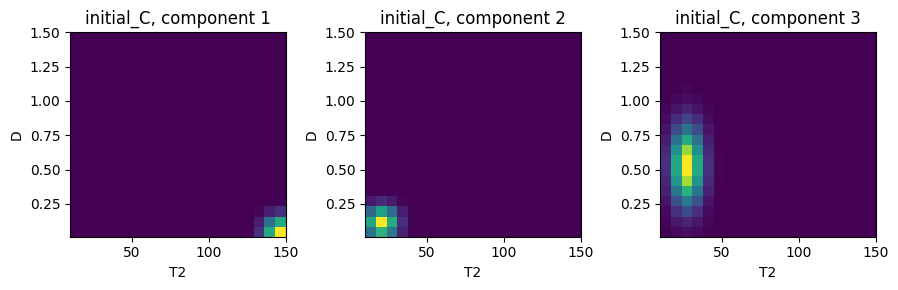

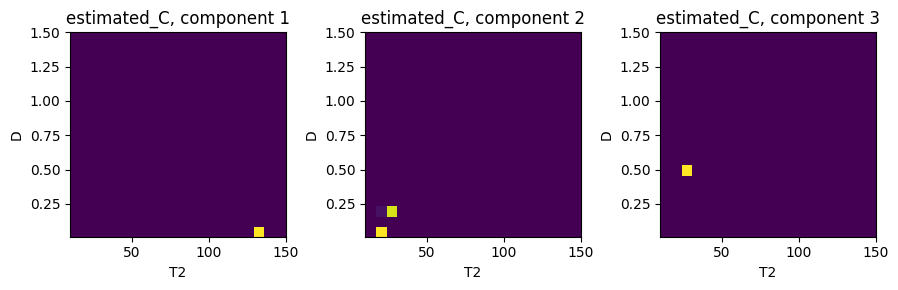

Estimated M0 (median, range): 1047.8649020893408 944.905400515047 1419.0539452762769
sigma2: initial 140.1558707177177  final 140.1558707177177


In [60]:
# noise level from the data: residual of the initial fit
Y_init_pred = (U @ Csmall0 @ W0) * M0_init
sigma2_init = np.mean((Y - Y_init_pred) ** 2)
print("sigma2 from initial fit:", sigma2_init)

W_est, M0_est, C_est, alpha_est, sigma2_est, lam_est, losses, fit_errs = (
    run_constrained_optimisation(
        Y, U, s, Vmat,
        C0, M0_init,
        K=K,
        n_iter=300,
        sigma2=sigma2_init,
        lam=1e-8,
        W=W0,

        update_W_flag=True,
        update_C_flag=True,
        update_M0_flag=True,
        m0_prior=M0_init,
        m0_prior_sigma=0.15,

        alpha=1.0,
        update_alpha_flag=False,
        alpha_update_start=5,
        weight_entropy=0.0,

        c_sparsity=0.0,
        c_smoothness=0.0,
        c_diversity=0.0,
        c_maxiter=100,
        nD=nD,
        nT2=nT2,

        verbose_every=100,
    )
)

# order by mean D (low to high), same as for C0
idx = np.argsort((D @ C_est) / C_est.sum(axis=0))
C_est, W_est = C_est[:, idx], W_est[idx]
F_est = C_est @ W_est

show_canonical_spectra([('initial_C', C0)])
show_canonical_spectra([('estimated_C', C_est)])
print("Estimated M0 (median, range):", np.median(M0_est), M0_est.min(), M0_est.max())
print("sigma2: initial", sigma2_init, " final", sigma2_est)

Maria's note: Starting from the signal-averaged initialisation, the weights are recovered well. The spectra shrink to single spikes at roughly the right positions, so the peak locations are right but the shape and width are lost




Note this constrained optimisation of C (not C_small) has several constraint options:

- c_smoothness
Makes each canonical D–T2 spectrum spatially smooth across neighbouring grid cells.

- c_sparsity
Encourages each canonical spectrum to concentrate its mass into fewer grid locations.

- c_diversity
Discourages different canonical spectra from overlapping at the same D–T2 locations.

Other constraints already in the model (not on C):

- C simplex constraint
Each canonical spectrum is non-negative and sums to one.

- W simplex constraint
Each voxel’s component weights are non-negative and sum to one.

- M0 > 0
Voxel signal scale cannot be negative.

- lam
Ridge/Gaussian penalty on reduced C_small; shrinks its overall magnitude. Not physical D–T2 smoothness.

- Dirichlet alpha on W
A probabilistic prior favouring globally more pure (alpha < 1) or more even (alpha > 1) voxel weights.

- weight_entropy
Non-Dirichlet alternative that encourages individual voxel weights to be sparse/dominant.

#### We can make C smoother with the smoothness option

# 2. How about estimating C_small

iter 0: loss=727.5390, fit_err=305253.950800, sigma2=191.540979, lam=0.0000, alpha=1.0000
iter 1: loss=722.3216, fit_err=303261.523972, sigma2=191.540979, lam=0.0000, alpha=1.0000
iter 2: loss=721.5522, fit_err=302966.785944, sigma2=191.540979, lam=0.0000, alpha=1.0000
iter 3: loss=721.0310, fit_err=302767.114993, sigma2=191.540979, lam=0.0000, alpha=1.0000
iter 4: loss=720.6417, fit_err=302617.974599, sigma2=191.540979, lam=0.0000, alpha=1.0000
iter 5: loss=720.3296, fit_err=302498.389991, sigma2=191.540979, lam=0.0000, alpha=1.0000
iter 6: loss=720.0658, fit_err=302397.359059, sigma2=191.540979, lam=0.0000, alpha=1.0000
iter 7: loss=719.8354, fit_err=302309.098078, sigma2=191.540979, lam=0.0000, alpha=1.0000
iter 8: loss=719.6303, fit_err=302230.503501, sigma2=191.540979, lam=0.0000, alpha=1.0000
iter 9: loss=719.4458, fit_err=302159.822644, sigma2=191.540979, lam=0.0000, alpha=1.0000
iter 10: loss=719.2791, fit_err=302095.976808, sigma2=191.540979, lam=0.0000, alpha=1.0000
iter 11: 

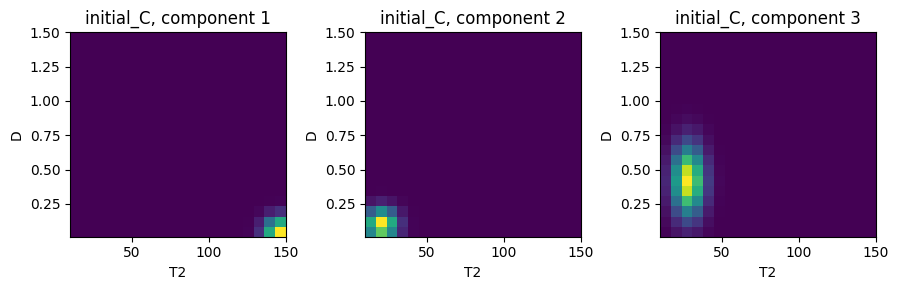

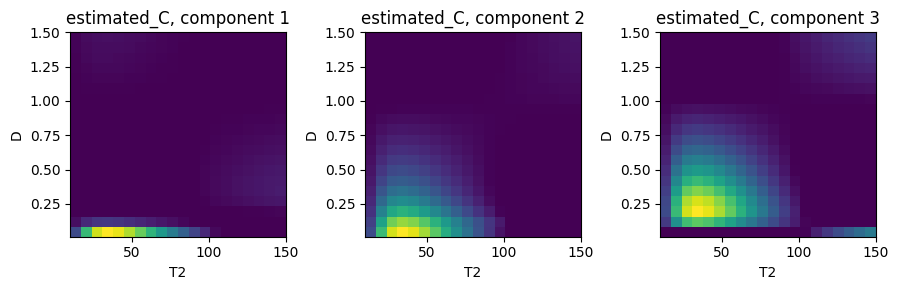

Estimated M0: [1383.92807062 1132.51693628 1111.32345042 1040.62507715 1029.94729594
 1258.64716655 1048.20287735 1299.85594548 1188.302427   1120.05352303
 1016.94777521 1175.73015582 1327.75981538 1219.1700493  1203.89899934
  974.28206988 1173.29790901 1055.14242847  990.28735184  949.90455347
  959.72527428  971.1309172   928.33594206  980.47026991  886.37223661
 1009.07247856  936.41764881 1003.67303274 1053.48003679 1147.40433287
  934.92599243 1026.03700276  922.63344571 1232.41361017 1183.34431883
 1289.8157428  1163.48450772  846.8212519   235.02052921  204.13182234
  179.09221666  378.99351389  955.34155313  963.58627028  772.79327154
  420.37332198 1165.96480059 1004.02247357  182.2708051  1033.37612557
  796.06879568  986.61403302  959.4953401  1315.36190311 1251.31329606
 1050.75130493  511.1796573   900.23259601 1094.23359371  935.20528075
  825.27647935 1042.24096214  970.60458517  977.6401188  1028.56545059
 1000.32424573 1445.33164937  928.22485717  885.4231097   895.9

In [51]:
# CODE AT THE TOP HERE SO YOU CAN TRY DIFFERENT RANKS
R = 8
U, s, Vmat = apply_SVD_to_A(A, R)

# C0 stays on the physical D–T2 grid, so it does not depend on R.
Csmall0 = project_C_to_C_small(C0, s, Vmat)

# Refit weights because U @ Csmall0 has changed.
W0 = initialize_W_from_C(Y, U, Csmall0, M0_init, bound_eps=1e-3)

# noise level from the residual of the initial fit (no ground-truth sigma)
sigma2_init = np.mean((Y - (U @ Csmall0 @ W0) * M0_init) ** 2)

# Here we use run_optimisation not run_optimisation_constrained 
W_est, M0_est, Csmall_est, alpha_est, sigma2_est, lam_est, losses, fit_errs = (
    run_optimisation(
        Y, U,
        Csmall0, M0_init,
        K=K, R=R,
        eps=1e-10,
        n_iter=300,
        sigma2=sigma2_init,
        lam=1e-8,
        W=W0,

        update_W_flag=True,
        update_C_flag=True,
        update_M0_flag=True,
        m0_prior=M0_init,   # set M0 prior as Gaussian around initial guess
        m0_prior_sigma=0.15,

        alpha=1.0,
        update_alpha_flag=False,
        alpha_update_start=5,      # allow C/W to settle first
        #weight_entropy=0.0,        # do not combine with entropy here

        #c_sparsity=0.0,
        #c_smoothness=0.0,
        #c_diversity=0.0,
        #c_maxiter=100,

        verbose_every=1,
    )
)

C_est = estimate_C(Vmat, s, Csmall_est)

F_est = C_est @ W_est

show_canonical_spectra([('initial_C', C0)])
show_canonical_spectra([('estimated_C', C_est)])
print("Estimated M0:", M0_est)

#### The spectra are a bit dodgy - can change R to adjust this, but the weights actually look quite good regardless. Could fit peaks afterwards?

Maria's note: Agreed. The C_small spectra are smooth but spread mass across the grid, while the weights stay good. Fitting peak positions afterwards looks like the right next step.


## 3. What happens if you set a Drichilet prior and try to estimate W and C_small?
Trying to recreate Maria's issues

iter 0: loss=1621.9287, fit_err=1293482.353033, sigma2=382.406256, lam=0.0000, alpha=1.0000
iter 1: loss=1620.3258, fit_err=1292258.219418, sigma2=382.406256, lam=0.0000, alpha=1.0000
iter 2: loss=1620.3210, fit_err=1292254.510108, sigma2=382.406256, lam=0.0000, alpha=1.0000
iter 3: loss=1620.3210, fit_err=1292254.499548, sigma2=382.406256, lam=0.0000, alpha=1.0000
iter 4: loss=1620.3210, fit_err=1292254.499211, sigma2=382.406256, lam=0.0000, alpha=1.0000
iter 5: loss=1603.8624, fit_err=1292254.498909, sigma2=382.406256, lam=0.0000, alpha=0.6450
iter 6: loss=1598.6176, fit_err=1292658.941240, sigma2=382.406256, lam=0.0000, alpha=0.6056
iter 7: loss=1580.8826, fit_err=1293207.868873, sigma2=382.406256, lam=0.0000, alpha=0.5208
iter 8: loss=1551.2576, fit_err=1295625.195606, sigma2=382.406256, lam=0.0000, alpha=0.4336
iter 9: loss=1522.7985, fit_err=1300970.301749, sigma2=382.406256, lam=0.0000, alpha=0.3755
iter 10: loss=1510.8672, fit_err=1306149.451305, sigma2=382.406256, lam=0.0000, 

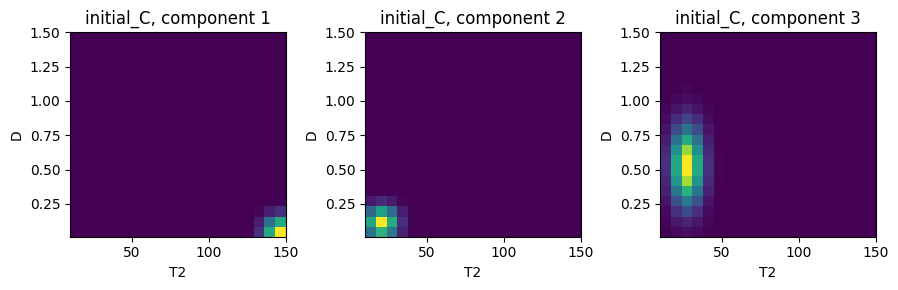

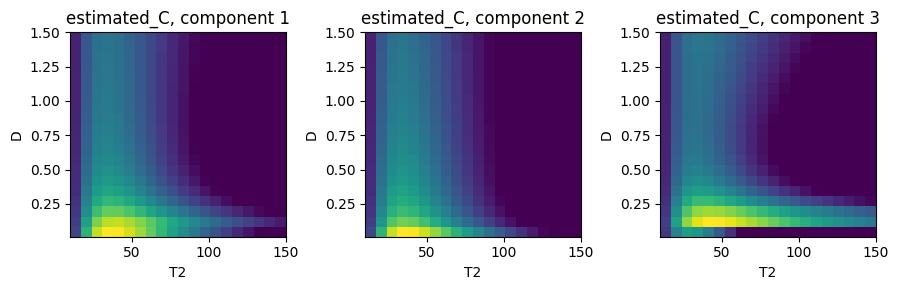

Estimated M0: [ 982.43783024  987.56695407  981.59410455 1038.08624813 1051.88704219
  992.47505752 1052.03096929 1021.76388435 1008.45681155 1056.11587021
 1004.0136164  1051.2413212  1057.05063187 1012.61503886 1042.69332946
 1016.38323198 1028.67881386  964.32134582 1012.7125774  1063.83396047
 1025.39552594 1019.9205237  1093.87776887  963.01229743 1001.06461165
 1023.97692461 1073.60133388 1110.47989696 1111.01317813 1105.10175252
 1071.20153156 1071.99607181 1014.32407854 1116.4272965   997.89801256
 1025.29894578 1081.73386597 1041.84901882 1112.37635502  995.03089196
 1112.99587311 1107.95012607 1073.88705073 1048.97489815 1051.98976074
 1021.73986045 1152.84488978 1097.04643271 1046.75410401 1085.47497793
 1001.43469518 1036.31580791 1188.25807736 1028.63575508 1178.41886601
 1053.3347884  1018.25135105  984.57008622 1039.50469213 1207.20739902
 1114.37867274 1071.06027203  981.56520564  991.63546204 1042.34644604
 1315.25764013 1036.13937152 1079.24730658 1141.71445956 1419.0

In [61]:
# 

R = 5
U, s, Vmat = apply_SVD_to_A(A, R)

# C0 stays on the physical D–T2 grid, so it does not depend on R.
Csmall0 = project_C_to_C_small(C0, s, Vmat)

# Refit weights because U @ Csmall0 has changed.
W0 = initialize_W_from_C(Y, U, Csmall0, M0_init, bound_eps=1e-3)

# noise level from the residual of the initial fit (no ground-truth sigma)
sigma2_init = np.mean((Y - (U @ Csmall0 @ W0) * M0_init) ** 2)

W_est, M0_est, Csmall_est, alpha_est, sigma2_est, lam_est, losses, fit_errs = (
    run_optimisation(
        Y, U,
        Csmall0, M0_init,
        K=K, R=R,
        eps=1e-10,
        n_iter=20,
        sigma2=sigma2_init,
        lam=1e-8,
        W=W0,

        update_W_flag=True,
        update_C_flag=True,
        update_M0_flag=True,
        m0_prior=M0_init,   # set M0 prior as Gaussian around initial guess
        m0_prior_sigma=0.15,

        alpha=1.0,
        update_alpha_flag=True,
        alpha_update_start=5,      # allow C/W to settle first
        #weight_entropy=0.0,        # do not combine with entropy here

        #c_sparsity=0.0,
        #c_smoothness=0.0,
        #c_diversity=0.0,
        #c_maxiter=100,

        verbose_every=1,
    )
)


C_est = estimate_C(Vmat, s, Csmall_est)

F_est = C_est @ W_est

print("alpha:", alpha_est)

show_canonical_spectra([('initial_C', C0)])
show_canonical_spectra([('estimated_C', C_est)])

print("Estimated M0:", M0_est)

iter 0: loss=207.1088, fit_err=102549.468180, sigma2=185.508033, lam=0.0000, alpha=1.0000
prior: final fit error 1.094e+05, alpha 0.28663089669472075


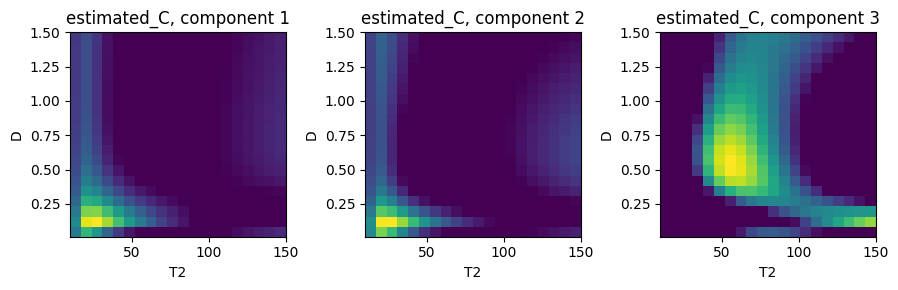

iter 0: loss=792.9948, fit_err=102485.100660, sigma2=185.508033, lam=0.0000, alpha=1.0000
prior: final fit error 1.14e+05, alpha 1.0


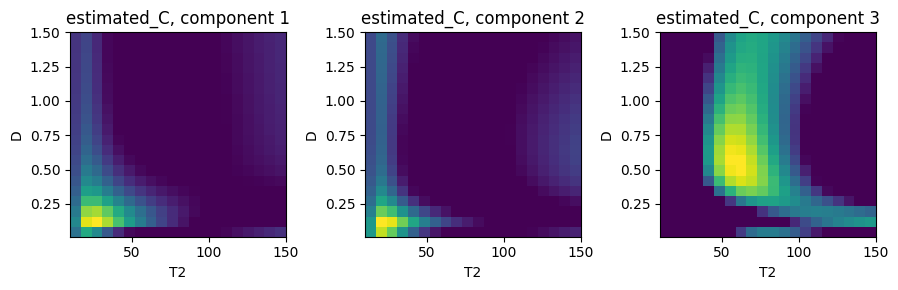

W difference between priors (MAE): 0.003


In [68]:
# Dirichlet vs entropy prior on the same real data
priors = {
    "dirichlet": dict(update_alpha_flag=True, weight_entropy=0.0),
    "entropy": dict(update_alpha_flag=False, weight_entropy=10.0),
}

R = 10
U, s, Vmat = apply_SVD_to_A(A, R)

# C0 stays on the physical D–T2 grid, so it does not depend on R.
Csmall0 = project_C_to_C_small(C0, s, Vmat)

# Refit weights because U @ Csmall0 has changed.
W0 = initialize_W_from_C(Y, U, Csmall0, M0_init, bound_eps=1e-3)

# noise level from the residual of the initial fit (no ground-truth sigma)
sigma2_init = np.mean((Y - (U @ Csmall0 @ W0) * M0_init) ** 2)

results = {}
for name, kwargs in priors.items():
    W_est_prior, M0_est_prior, Csmall_est_prior, alpha_est_prior, _, _, losses_prior, fit_errs_prior = run_optimisation(
        Y, U, Csmall0, M0_init, K=K, R=R, eps=1e-10, n_iter=300,
        sigma2=sigma2_init, lam=1e-8, W=W0.copy(),
        update_W_flag=True, update_C_flag=True, update_M0_flag=True,
        m0_prior=M0_init, m0_prior_sigma=0.15, alpha=1.0, alpha_update_start=5,
        verbose_every=300, **kwargs)
    C_est_prior = estimate_C(Vmat, s, Csmall_est_prior)
    results[name] = (C_est_prior, W_est_prior)
    print(f"prior: final fit error {fit_errs_prior[-1]:.4g}, alpha {alpha_est_prior}")
    show_canonical_spectra([(f'estimated_C', C_est_prior)])

# match entropy components to dirichlet ones, then compare
C_dir, W_dir = results["dirichlet"]
C_ent, W_ent = order_components(C_dir, *results["entropy"], K)
print("W difference between priors (MAE):", np.round(np.mean(np.abs(W_dir - W_ent)), 3))

## 4. Mixed vs single diffusion time (Δ)
Runs 1 and 3 use a different Δ from runs 2, 4, 5, 6. If diffusion is restricted, the apparent D changes with Δ, so mixing them breaks the one-D-per-compartment assumption.
Here the same 100 voxels are fitted twice with identical settings: all 6 runs vs runs [2, 4, 5, 6] only. Only the runs change: same b-values, same grid, same initialisation method, and both datasets are scaled by the b=0, TE=33 ms signal (present in both).
If the peaks move in D (or a component changes a lot), the mixed Δ was affecting the result.


=== all 6 runs: runs [1, 2, 3, 4, 5, 6] ===
iter 0: loss=220.5459, fit_err=143329.099055, sigma2=247.250509, lam=0.0000, alpha=1.0000

=== single Δ: runs [2, 4, 5, 6] ===
iter 0: loss=91.1280, fit_err=109497.932218, sigma2=341.242685, lam=0.0000, alpha=1.0000

all 6 runs: 48 measurements, relative RMS residual 4.623%, mean |W - W0| 0.005
  component 1: peak (D, T2) = (0.17, 25)   centroid = (0.41, 47)   mean weight 0.23
  component 2: peak (D, T2) = (0.01, 25)   centroid = (0.50, 54)   mean weight 0.05
  component 3: peak (D, T2) = (0.09, 17)   centroid = (0.58, 46)   mean weight 0.72


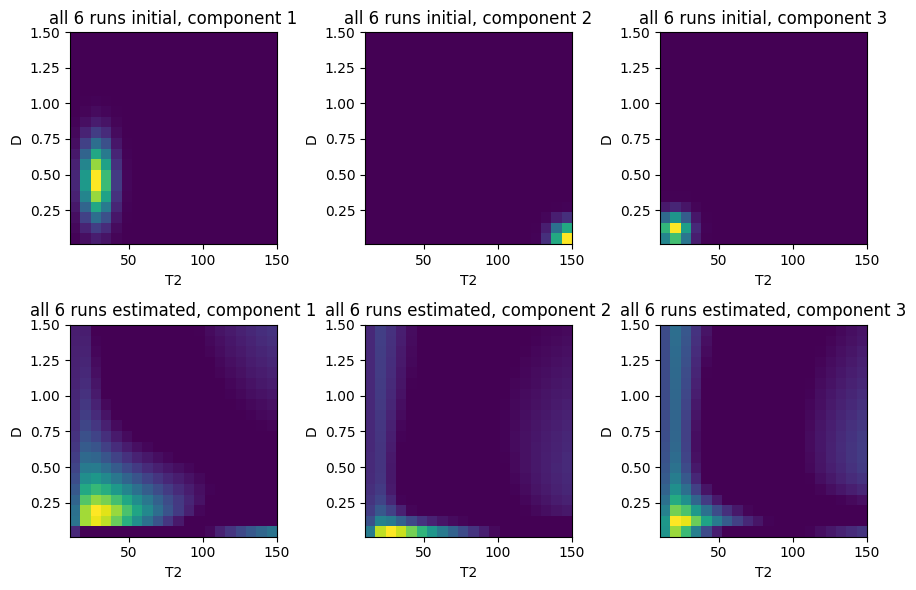


single Δ: 32 measurements, relative RMS residual 6.538%, mean |W - W0| 0.006
  component 1: peak (D, T2) = (0.01, 25)   centroid = (0.54, 54)   mean weight 0.07
  component 2: peak (D, T2) = (0.09, 25)   centroid = (0.58, 46)   mean weight 0.92
  component 3: peak (D, T2) = (0.64, 54)   centroid = (0.77, 71)   mean weight 0.01


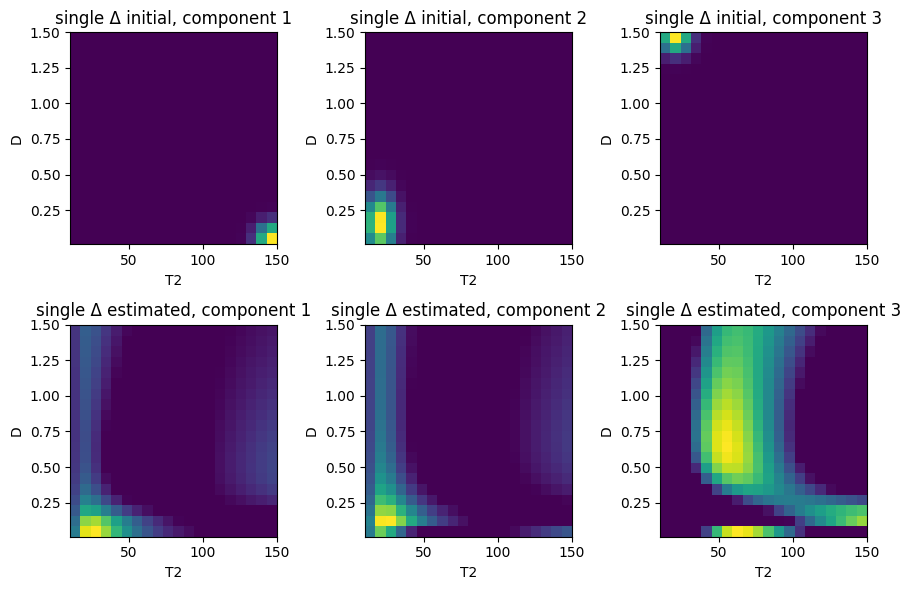

W difference between mixed and single Δ (MAE, components ordered by mean D): 0.581


In [75]:
# Both datasets are rebuilt from the raw slice so they go through identical preparation.
# Self-contained loading; only needs `near` (voxel selection cell) and the grid/K from above.
import os
import nibabel as nib
from scipy.ndimage import binary_dilation

DATA_DIR_CMP  = "/Users/mb4725/Library/CloudStorage/OneDrive-ImperialCollegeLondon/PhD/Code/Dataset_macaque"
MASK_PATH_CMP = os.path.join(DATA_DIR_CMP, "preprocessed", "WM_mask_dwispace.nii.gz")
SLICE_CMP     = 42   # must match the slice of Y_slice42.npy, so `near` points at the same voxels
TE_BY_RUN_CMP = {1: 28.12, 2: 33.0, 3: 38.017, 4: 45.0, 5: 60.0, 6: 78.0}
BVALS_CMP     = np.array([0.0, 1000.0, 2500.0, 5000.0, 7500.0, 11100.0, 18100.0, 25000.0])
BVAL_TOL_CMP  = 50.0

RUN_SETS = {"all 6 runs": [1, 2, 3, 4, 5, 6], "single Δ": [2, 4, 5, 6]}
R_cmp, n_iter_cmp = 10, 300

mask_slice_cmp = nib.load(MASK_PATH_CMP).get_fdata()[:, :, SLICE_CMP] > 0

# background = well outside the brain, away from the image edges (used for the floor correction)
brain_cmp = nib.load(os.path.join(DATA_DIR_CMP, "bet4animal_brainmask_f08_mask.nii.gz")).get_fdata()[:, :, SLICE_CMP] > 0
bg_cmp = ~binary_dilation(brain_cmp, iterations=10)
bg_cmp[:5] = bg_cmp[-5:] = False
bg_cmp[:, :5] = bg_cmp[:, -5:] = False


def build_Y(runs, floor="none"):
    # floor: "none", "subtract" (additive pedestal: minus background mean) or
    #        "quadrature" (Rician-type floor: sqrt(M^2 - background mean square)); both per volume
    rows, acq_rows = [], []
    for run_idx in runs:
        stem = os.path.join(DATA_DIR_CMP, f"sub-M1_acq-MultiDim_run-{run_idx}_dwi")
        img = nib.load(stem + ".nii.gz")
        slice_data = np.asarray(img.dataobj[:, :, SLICE_CMP, :], dtype=np.float32)
        data = slice_data[mask_slice_cmp][near]    # (100, nvol): same voxels as above
        bg_vals = slice_data[bg_cmp]              # (n_bg, nvol)
        if floor == "subtract":
            data = data - bg_vals.mean(axis=0)
        elif floor == "quadrature":
            data = np.sqrt(np.maximum(data ** 2 - np.mean(bg_vals ** 2, axis=0), 0))
        bvals = np.loadtxt(stem + ".bval").ravel()
        for bval in BVALS_CMP:
            sel = np.abs(bvals - bval) <= BVAL_TOL_CMP
            rows.append(data[:, sel].mean(axis=1))
            acq_rows.append((bval / 1000.0, TE_BY_RUN_CMP[run_idx]))   # b in ms/µm²
    Y_r, acq_r = np.stack(rows), np.array(acq_rows)
    # b=0, TE=33 ms exists in both run sets, so both get the same intensity scale
    ref = (acq_r[:, 0] == 0) & (acq_r[:, 1] == TE_BY_RUN_CMP[2])
    Y_r = Y_r / np.median(Y_r[ref]) * 300
    order = np.lexsort((acq_r[:, 1], acq_r[:, 0]))      # b-major, like the main fit
    return Y_r[order], acq_r[order, 0], acq_r[order, 1]


def fit_dataset(Y_r, b_r, TE_r):
    A_r = np.exp(-np.outer(b_r, D)) * np.exp(-np.outer(TE_r, 1.0 / T2))
    U_r, s_r, V_r = apply_SVD_to_A(A_r, R_cmp)
    C0_r = define_initial_C_NNLS_mean(Y_r, A_r, range(Y_r.shape[1]), K, D_vals, T2_vals,
                                      D_vals.min(), D_vals.max(), T2_vals.min(), T2_vals.max(), nD, nT2)
    Cs0_r = project_C_to_C_small(C0_r, s_r, V_r)
    M0_r = initialize_M0_monoexponential(Y_r, np.unique(b_r), np.unique(TE_r))
    W0_r = initialize_W_from_C(Y_r, U_r, Cs0_r, M0_r, bound_eps=1e-3)
    sigma2_r = np.mean((Y_r - (U_r @ Cs0_r @ W0_r) * M0_r) ** 2)

    W_r, M0e_r, Cs_r, *_ = run_optimisation(
        Y_r, U_r, Cs0_r, M0_r, K=K, R=R_cmp, eps=1e-10, n_iter=n_iter_cmp,
        sigma2=sigma2_r, lam=1e-8, W=W0_r.copy(),
        update_W_flag=True, update_C_flag=True, update_M0_flag=True,
        m0_prior=M0_r, m0_prior_sigma=0.15,
        alpha=1.0, update_alpha_flag=False, alpha_update_start=5,
        verbose_every=n_iter_cmp)
    C_r = estimate_C(V_r, s_r, Cs_r)

    # components keep their identity through the fit, so one ordering (by mean D) applies to C0, W0, C, W
    idx = np.argsort((D @ C_r) / C_r.sum(axis=0))
    resid = Y_r - (U_r @ Cs_r @ W_r) * M0e_r
    return dict(C0=C0_r[:, idx], C=C_r[:, idx], W0=W0_r[idx], W=W_r[idx],
                rel_rms=np.sqrt(np.mean(resid ** 2)) / np.mean(Y_r), n_meas=len(b_r))


def peak_and_centroid(c):
    iD, iT2 = np.unravel_index(np.argmax(c), (nD, nT2))
    return D_vals[iD], T2_vals[iT2], (D @ c) / c.sum(), (T2 @ c) / c.sum()


def report_fits(fits):
    for name, f in fits.items():
        print(f"\n{name}: {f['n_meas']} measurements, relative RMS residual {f['rel_rms']:.3%}, "
              f"mean |W - W0| {np.mean(np.abs(f['W'] - f['W0'])):.3f}")
        for k in range(K):
            pD, pT2, cD, cT2 = peak_and_centroid(f["C"][:, k])
            print(f"  component {k + 1}: peak (D, T2) = ({pD:.2f}, {pT2:.0f})   "
                  f"centroid = ({cD:.2f}, {cT2:.0f})   mean weight {f['W'][k].mean():.2f}")
        show_canonical_spectra([(f"{name} initial", f["C0"]), (f"{name} estimated", f["C"])])


fits = {}
for name, runs in RUN_SETS.items():   # one fit at a time
    print(f"\n=== {name}: runs {runs} ===")
    fits[name] = fit_dataset(*build_Y(runs))
report_fits(fits)

W_mixed, W_single = (f["W"] for f in fits.values())
print("W difference between mixed and single Δ (MAE, components ordered by mean D):",
      np.round(np.mean(np.abs(W_mixed - W_single)), 3))

## 5. Signal floor
The corner component at (D ≈ 0.01, T2 ≈ 150) decays with neither b nor TE, which looks like a floor rather than tissue.

What the background (well outside the brain) shows on slice 42:
- **The level is high:** it sits at about 4500–5000 in every volume and barely changes with b. The ROI signal at TE 60/78 is only 1.3–3× that level.
- **It isn't pure noise:** std/mean is about 0.13–0.2, whereas pure magnitude noise (Rayleigh) gives 0.52. The noise inside the tissue is also much smaller (median spread across the b=25000 directions at TE 78 is about 330).
- **So it looks like a pedestal:** an additive offset, probably from the 73% partial-sampling reconstruction, rather than a Rician floor. The right correction is then to **subtract** the background mean from each volume. Quadrature correction (`floor="quadrature"`) is kept as an option.
- **Dropping shells is a poor option:** at TE 60/78 almost every shell sits close to the level, so it would discard most of the long-TE data.
- **The offset isn't fitted freely:** a free constant is almost indistinguishable from the corner component, so it is measured from the background instead.

If subtraction is right, the corner component should disappear and the high-b signal should stop having an implausibly long apparent T2.

apparent T2 (ms) between TE 60 and 78, ROI mean signal
b (ms/µm²)        none    subtract
       0.0          29          22
       1.0          30          22
       2.5          33          22
       5.0          39          23
       7.5          41          22
      11.1          50          24
      18.1          71          31
      25.0         100          44

=== floor = none ===
iter 0: loss=220.5459, fit_err=143329.099055, sigma2=247.250509, lam=0.0000, alpha=1.0000

=== floor = subtract ===
iter 0: loss=865.4407, fit_err=269906.429412, sigma2=144.379552, lam=0.0000, alpha=1.0000

floor=none: 48 measurements, relative RMS residual 4.623%, mean |W - W0| 0.005
  component 1: peak (D, T2) = (0.17, 25)   centroid = (0.41, 47)   mean weight 0.23
  component 2: peak (D, T2) = (0.01, 25)   centroid = (0.50, 54)   mean weight 0.05
  component 3: peak (D, T2) = (0.09, 17)   centroid = (0.58, 46)   mean weight 0.72


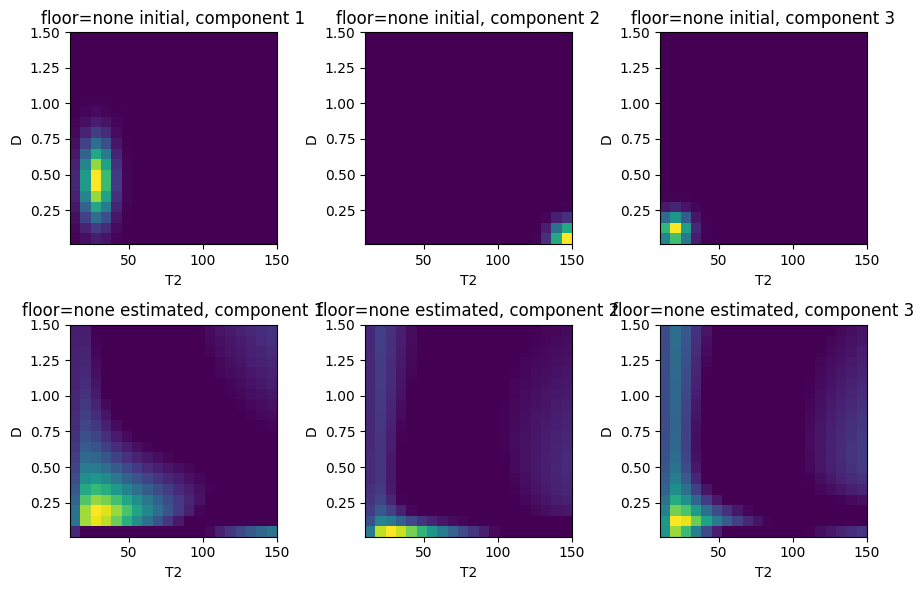


floor=subtract: 48 measurements, relative RMS residual 6.059%, mean |W - W0| 0.076
  component 1: peak (D, T2) = (0.09, 25)   centroid = (0.51, 43)   mean weight 0.18
  component 2: peak (D, T2) = (0.09, 17)   centroid = (0.55, 45)   mean weight 0.73
  component 3: peak (D, T2) = (0.09, 17)   centroid = (0.58, 44)   mean weight 0.09


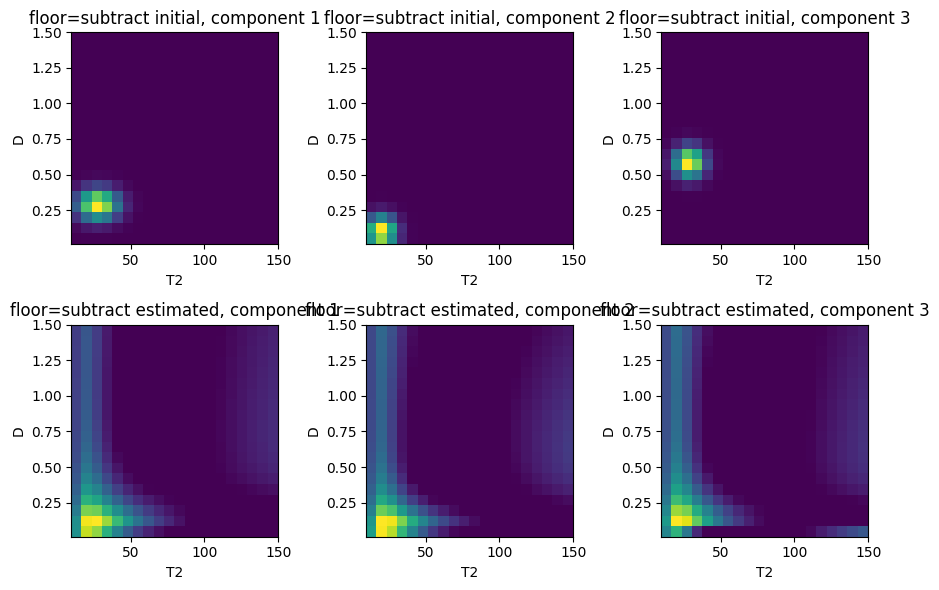

In [76]:
# Uses build_Y / fit_dataset / report_fits from section 4 (run that cell first).
FLOOR_MODES = ["none", "subtract"]   # add "quadrature" to compare the Rician-type correction too
FLOOR_RUNS  = [1, 2, 3, 4, 5, 6]

# Diagnostic: apparent T2 between TE 60 and 78 ms at each b. A floor makes it grow with b,
# because the non-decaying part takes over as the tissue signal falls.
floor_data = {mode: build_Y(FLOOR_RUNS, floor=mode) for mode in FLOOR_MODES}
print("apparent T2 (ms) between TE 60 and 78, ROI mean signal")
print("b (ms/µm²)  " + "  ".join(f"{mode:>10}" for mode in FLOOR_MODES))
for b in np.unique(floor_data["none"][1]):
    t2s = []
    for mode in FLOOR_MODES:
        Y_m, b_m, TE_m = floor_data[mode]
        s60, s78 = (Y_m[(b_m == b) & (TE_m == te)].mean() for te in (60.0, 78.0))
        t2s.append((78.0 - 60.0) / np.log(s60 / s78) if s60 > s78 > 0 else np.nan)
    print(f"{b:>10.1f}  " + "  ".join(f"{t2:>10.0f}" for t2 in t2s))

floor_fits = {}
for mode in FLOOR_MODES:   # one fit at a time
    print(f"\n=== floor = {mode} ===")
    floor_fits[f"floor={mode}"] = fit_dataset(*floor_data[mode])
report_fits(floor_fits)